# Module 9: Spark vs Ray - A Practical Comparison

**DSC 232R - Big Data Analysis Using Spark**

This notebook covers:
1. Framework philosophies and design goals
2. API comparison for common operations
3. Hands-on performance comparison
4. When to choose each framework
5. Integration patterns for using both together

## Learning Objectives

- Understand when to choose Spark vs Ray for different workloads
- Implement the same task in both frameworks
- Measure and compare performance characteristics
- Make informed framework selection decisions

---

## 1. Framework Philosophy

### Apache Spark

**Design Goal**: Unified analytics engine for large-scale data processing

```
Data Lake → ETL → Analytics → ML → Data Warehouse
         ←────── Spark handles all of this ──────→
```

**Strengths**:
- Optimized for batch data processing
- Strong SQL support (Spark SQL)
- Mature ecosystem (MLlib, GraphX, Structured Streaming)
- Automatic optimization (Catalyst optimizer)

**Model**: Data-parallel operations on distributed collections (RDDs, DataFrames)

### Ray

**Design Goal**: Simple, universal framework for distributed computing

```
                    ┌─ Training ─┐
Python Function → Ray Task → │  Serving  │ → Results
                    └─ Tuning  ─┘
```

**Strengths**:
- Simple Python-native API (`@ray.remote`)
- Flexible task and actor model
- Excellent for ML workloads (Ray Train, Ray Tune, Ray Serve)
- Lower latency for small tasks

**Model**: Task-parallel execution of arbitrary Python functions

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


---

## 2. API Comparison

Let's compare how the same operations look in both frameworks.

In [ ]:
# Initialize both frameworks

# Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Framework-Comparison") \
    .master("local[4]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print(f"Spark initialized: {spark.version}")

Spark initialized: 4.0.2


In [ ]:
!pip install ray

In [ ]:
# Ray
import ray

if ray.is_initialized():
    ray.shutdown()

ray.init(num_cpus=4, ignore_reinit_error=True, logging_level="WARNING")

print(f"Ray initialized: {ray.__version__}")
print(f"Available resources: {ray.available_resources()}")

/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Ray initialized: 2.55.1
Available resources: {'CPU': 4.0, 'object_store_memory': 3976469299.0, 'node:172.28.0.12': 1.0, 'memory': 9278428365.0, 'node:__internal_head__': 1.0}


### Simple Map Operation

Let's compare how each framework handles a basic map operation:

In [ ]:
# Test data
test_numbers = list(range(10000))

# SPARK: Map operation
def spark_map_example():
    """Square numbers using Spark."""
    rdd = spark.sparkContext.parallelize(test_numbers)
    result = rdd.map(lambda x: x ** 2).collect()
    return result

# RAY: Map operation
@ray.remote
def square(x):
    return x ** 2

def ray_map_example_naive():
    """Square numbers using Ray (naive approach - too many tasks!)."""
    # WARNING: This creates 10K tasks - too many for small work!
    futures = [square.remote(x) for x in test_numbers]
    return ray.get(futures)

@ray.remote
def square_batch(numbers):
    """Square a batch of numbers."""
    return [x ** 2 for x in numbers]

def ray_map_example_batched():
    """Square numbers using Ray (batched - proper approach)."""
    batch_size = 1000
    batches = [test_numbers[i:i+batch_size]
               for i in range(0, len(test_numbers), batch_size)]
    futures = [square_batch.remote(batch) for batch in batches]
    results = ray.get(futures)
    return [item for sublist in results for item in sublist]  # Flatten

print("Map operation comparison:")
print(f"  Spark result (first 5): {spark_map_example()[:5]}")
print(f"  Ray result (first 5):   {ray_map_example_batched()[:5]}")

Map operation comparison:
  Spark result (first 5): [0, 1, 4, 9, 16]
  Ray result (first 5):   [0, 1, 4, 9, 16]


### Key Difference: Task Granularity

| Aspect | Spark | Ray |
|--------|-------|-----|
| Overhead per task | High (optimized for large batches) | Low (fine-grained tasks) |
| Ideal task size | 100K+ rows per partition | 1-1000 tasks typical |
| Scheduling | Batch-oriented | Fine-grained |

---

## 3. Hands-On Comparison: Distributed Aggregation

Let's implement the same meaningful task in both frameworks and compare.

In [ ]:
# Generate test data: 1 million numbers
np.random.seed(42)
large_data = np.random.randn(1_000_000)

print(f"Test data: {len(large_data):,} numbers")
print(f"Expected mean: ~0 (standard normal)")
print(f"Actual mean: {np.mean(large_data):.6f}")

Test data: 1,000,000 numbers
Expected mean: ~0 (standard normal)
Actual mean: -0.001600


In [ ]:
# SPARK Implementation
from pyspark.sql.functions import mean, stddev, count

def spark_compute_stats(data):
    """
    Compute statistics using Spark.

    Creates a DataFrame and uses Spark SQL aggregations.
    """
    # Create DataFrame
    df = spark.createDataFrame([(float(x),) for x in data], ["value"])

    # Compute statistics
    result = df.agg(
        mean("value").alias("mean"),
        stddev("value").alias("std"),
        count("value").alias("count")
    ).collect()[0]

    return {
        "mean": result["mean"],
        "std": result["std"],
        "count": result["count"]
    }

# Test Spark
start = time.time()
spark_result = spark_compute_stats(large_data)
spark_time = time.time() - start

print("Spark Results:")
print(f"  Mean:  {spark_result['mean']:.6f}")
print(f"  Std:   {spark_result['std']:.6f}")
print(f"  Count: {spark_result['count']:,}")
print(f"  Time:  {spark_time:.3f}s")

Spark Results:
  Mean:  -0.001600
  Std:   1.000189
  Count: 1,000,000
  Time:  27.186s


In [ ]:
# RAY Implementation
@ray.remote
def compute_partial_stats(data_chunk):
    """
    Compute partial statistics for a chunk of data.

    Returns sum, sum of squares, and count for later aggregation.
    """
    chunk_array = np.array(data_chunk)
    return {
        "sum": float(np.sum(chunk_array)),
        "sum_sq": float(np.sum(chunk_array ** 2)),
        "count": len(chunk_array)
    }

def ray_compute_stats(data, num_chunks=10):
    """
    Compute statistics using Ray.

    Splits data into chunks, computes partial stats in parallel,
    then combines results.
    """
    # Split data into chunks
    chunks = np.array_split(data, num_chunks)

    # Compute partial stats in parallel
    futures = [compute_partial_stats.remote(chunk.tolist()) for chunk in chunks]
    partial_results = ray.get(futures)

    # Combine results
    total_sum = sum(r["sum"] for r in partial_results)
    total_sum_sq = sum(r["sum_sq"] for r in partial_results)
    total_count = sum(r["count"] for r in partial_results)

    mean_val = total_sum / total_count
    # Variance = E[X^2] - E[X]^2
    variance = (total_sum_sq / total_count) - (mean_val ** 2)
    std_val = np.sqrt(variance)

    return {
        "mean": mean_val,
        "std": std_val,
        "count": total_count
    }

# Test Ray
start = time.time()
ray_result = ray_compute_stats(large_data)
ray_time = time.time() - start

print("Ray Results:")
print(f"  Mean:  {ray_result['mean']:.6f}")
print(f"  Std:   {ray_result['std']:.6f}")
print(f"  Count: {ray_result['count']:,}")
print(f"  Time:  {ray_time:.3f}s")

Ray Results:
  Mean:  -0.001600
  Std:   1.000188
  Count: 1,000,000
  Time:  0.506s


In [ ]:
# Compare results
print("\nComparison")
print("=" * 50)
print(f"{'Metric':<15} {'Spark':<15} {'Ray':<15}")
print("-" * 50)
print(f"{'Mean':<15} {spark_result['mean']:<15.6f} {ray_result['mean']:<15.6f}")
print(f"{'Std':<15} {spark_result['std']:<15.6f} {ray_result['std']:<15.6f}")
print(f"{'Time (s)':<15} {spark_time:<15.3f} {ray_time:<15.3f}")
print(f"{'Faster':<15} {'✓' if spark_time < ray_time else '':<15} {'✓' if ray_time < spark_time else '':<15}")


Comparison
Metric          Spark           Ray            
--------------------------------------------------
Mean            -0.001600       -0.001600      
Std             1.000189        1.000188       
Time (s)        27.186          0.506          
Faster                          ✓              


---

## 4. Scaling Comparison

Let's see how both frameworks scale with data size:

In [ ]:
def benchmark_frameworks(data_sizes, num_runs=3):
    """
    Benchmark both frameworks across different data sizes.
    """
    results = []

    for size in data_sizes:
        print(f"\nBenchmarking size: {size:,}")
        data = np.random.randn(size)

        # Spark timing (average of runs)
        spark_times = []
        for _ in range(num_runs):
            start = time.time()
            spark_compute_stats(data)
            spark_times.append(time.time() - start)

        # Ray timing (average of runs)
        ray_times = []
        for _ in range(num_runs):
            start = time.time()
            ray_compute_stats(data, num_chunks=max(4, size // 100000))
            ray_times.append(time.time() - start)

        results.append({
            'size': size,
            'spark_time': np.mean(spark_times),
            'ray_time': np.mean(ray_times)
        })

        print(f"  Spark: {np.mean(spark_times):.3f}s, Ray: {np.mean(ray_times):.3f}s")

    return results

# Run benchmark with smaller sizes for this notebook
data_sizes = [100_000, 500_000, 1_000_000, 2_000_000]
benchmark_results = benchmark_frameworks(data_sizes, num_runs=2)


Benchmarking size: 100,000
  Spark: 2.091s, Ray: 0.063s

Benchmarking size: 500,000
  Spark: 7.395s, Ray: 0.212s

Benchmarking size: 1,000,000
  Spark: 13.135s, Ray: 0.377s

Benchmarking size: 2,000,000
  Spark: 24.413s, Ray: 0.505s


/tmp/ipykernel_8146/502941696.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([f'{s//1000}K' for s in sizes])


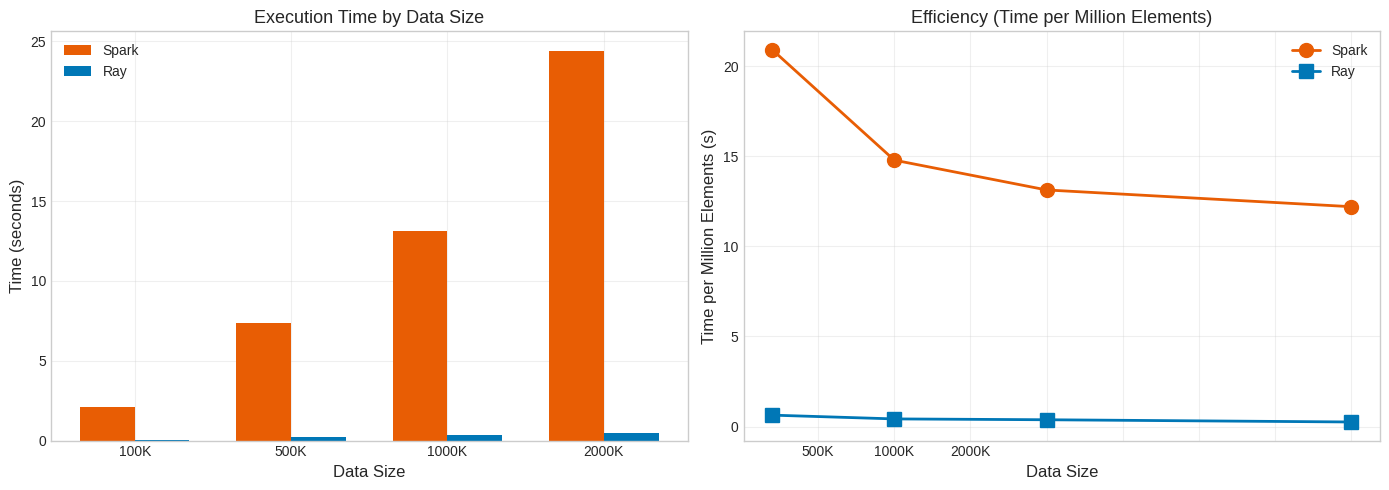

In [ ]:
# Visualize scaling comparison
sizes = [r['size'] for r in benchmark_results]
spark_times = [r['spark_time'] for r in benchmark_results]
ray_times = [r['ray_time'] for r in benchmark_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Absolute times
ax1 = axes[0]
x = range(len(sizes))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], spark_times, width, label='Spark', color='#E85D04')
bars2 = ax1.bar([i + width/2 for i in x], ray_times, width, label='Ray', color='#0077B6')

ax1.set_xlabel('Data Size', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time by Data Size', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{s//1000}K' for s in sizes])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Time per million elements
ax2 = axes[1]
spark_per_million = [t / (s / 1_000_000) for t, s in zip(spark_times, sizes)]
ray_per_million = [t / (s / 1_000_000) for t, s in zip(ray_times, sizes)]

ax2.plot(sizes, spark_per_million, 'o-', color='#E85D04', markersize=10, linewidth=2, label='Spark')
ax2.plot(sizes, ray_per_million, 's-', color='#0077B6', markersize=10, linewidth=2, label='Ray')

ax2.set_xlabel('Data Size', fontsize=12)
ax2.set_ylabel('Time per Million Elements (s)', fontsize=12)
ax2.set_title('Efficiency (Time per Million Elements)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels([f'{s//1000}K' for s in sizes])

plt.tight_layout()
plt.show()

---

## 5. When to Choose Each Framework

### Choose Spark When...

| Scenario | Why Spark |
|----------|----------|
| ETL pipelines | Optimized for data transformation |
| SQL queries on big data | Spark SQL with Catalyst optimizer |
| Batch processing | Designed for throughput over latency |
| Joining large datasets | Efficient distributed joins |
| Data warehousing | Native Parquet, Delta Lake support |
| Existing Hadoop ecosystem | HDFS, Hive integration |

### Choose Ray When...

| Scenario | Why Ray |
|----------|--------|
| ML model training | Ray Train with XGBoost, PyTorch, TensorFlow |
| Hyperparameter tuning | Ray Tune built-in |
| Model serving | Ray Serve for deployment |
| Reinforcement learning | RLlib |
| Stateful computations | Actor model |
| Low-latency tasks | Fine-grained scheduling |
| Custom parallelism | Flexible task model |

### Choose Both (Hybrid) When...

| Scenario | How to Combine |
|----------|----------------|
| ETL → ML Training | Spark for data prep → Ray for training |
| Feature engineering → Model | Spark SQL → Ray Train |
| Batch + Real-time | Spark Streaming + Ray Serve |
| Large data + Custom ML | Spark reads Parquet → Ray processes |

In [ ]:
# Decision flowchart
decision_flowchart = """
FRAMEWORK SELECTION DECISION TREE
==================================

1. Is your workload primarily data transformation (ETL)?
   └─ Yes → SPARK
   └─ No → Continue

2. Do you need to run SQL queries on large datasets?
   └─ Yes → SPARK
   └─ No → Continue

3. Are you training ML models with hyperparameter tuning?
   └─ Yes → RAY TRAIN
   └─ No → Continue

4. Do you need model serving with low latency?
   └─ Yes → RAY SERVE
   └─ No → Continue

5. Is your workload a mix of ETL and ML?
   └─ Yes → BOTH (Spark for ETL, Ray for ML)
   └─ No → Continue

6. Do you need stateful distributed objects (actors)?
   └─ Yes → RAY
   └─ No → SPARK (default for batch processing)
"""

print(decision_flowchart)


FRAMEWORK SELECTION DECISION TREE

1. Is your workload primarily data transformation (ETL)?
   └─ Yes → SPARK
   └─ No → Continue

2. Do you need to run SQL queries on large datasets?
   └─ Yes → SPARK
   └─ No → Continue

3. Are you training ML models with hyperparameter tuning?
   └─ Yes → RAY TRAIN
   └─ No → Continue

4. Do you need model serving with low latency?
   └─ Yes → RAY SERVE
   └─ No → Continue

5. Is your workload a mix of ETL and ML?
   └─ Yes → BOTH (Spark for ETL, Ray for ML)
   └─ No → Continue

6. Do you need stateful distributed objects (actors)?
   └─ Yes → RAY
   └─ No → SPARK (default for batch processing)



---

## 6. Integration Patterns: Using Both Together

The real power comes from using both frameworks together!

In [ ]:
# Pattern 1: Spark for ETL → Ray for ML
print("Integration Pattern: Spark ETL → Ray ML")
print("=" * 50)

# Step 1: Prepare data with Spark
from pyspark.sql.functions import col, when

# Create sample "raw" data
raw_data = [(i, f"cat_{i % 5}", np.random.random() * 100, np.random.random())
            for i in range(10000)]
raw_df = spark.createDataFrame(raw_data, ["id", "category", "feature1", "feature2"])

# ETL with Spark
processed_df = raw_df \
    .filter(col("feature1") > 10) \
    .withColumn("target", when(col("feature1") > 50, 1).otherwise(0)) \
    .select("feature1", "feature2", "target")

# Convert to Pandas for Ray
train_data = processed_df.toPandas()

print(f"Processed data shape: {train_data.shape}")
print(f"Target distribution: {train_data['target'].value_counts().to_dict()}")

Integration Pattern: Spark ETL → Ray ML
Processed data shape: (9024, 3)
Target distribution: {1: 5062, 0: 3962}


In [ ]:
# Step 2: Train with Ray
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

@ray.remote
def train_model_with_params(X_train, y_train, X_test, y_test, C):
    """
    Train a model with given regularization parameter.
    This could be extended to full hyperparameter tuning.
    """
    model = LogisticRegression(C=C, max_iter=200)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    return {"C": C, "accuracy": accuracy}

# Prepare data
X = train_data[["feature1", "feature2"]].values
y = train_data["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parallel hyperparameter search with Ray
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

print("\nParallel hyperparameter search with Ray:")
futures = [train_model_with_params.remote(X_train, y_train, X_test, y_test, C)
           for C in C_values]
results = ray.get(futures)

print(f"{'C':>10} {'Accuracy':>12}")
print("-" * 25)
for r in sorted(results, key=lambda x: x['accuracy'], reverse=True):
    print(f"{r['C']:>10} {r['accuracy']:>12.4f}")

best = max(results, key=lambda x: x['accuracy'])
print(f"\nBest: C={best['C']} with accuracy={best['accuracy']:.4f}")


Parallel hyperparameter search with Ray:
         C     Accuracy
-------------------------
      0.01       1.0000
       0.1       1.0000
       1.0       1.0000
      10.0       1.0000
     100.0       1.0000

Best: C=0.01 with accuracy=1.0000


### Integration Summary

```python
# Pattern: Spark ETL → Ray Training
# ===================================

# Step 1: Prepare data with Spark (good for large-scale ETL)
spark_df = spark.read.parquet("raw_data")
processed = spark_df.filter(...).select(...).groupBy(...)
processed.write.parquet("processed_data")

# Step 2: Train with Ray (good for ML training)
import ray
from ray.train.xgboost import XGBoostTrainer

trainer = XGBoostTrainer(
    label_column="target",
    datasets={"train": ray.data.read_parquet("processed_data")}
)
result = trainer.fit()
```

### Pattern 2: RayDP (Spark on Ray)

RayDP runs Spark as a library on top of Ray, enabling zero-copy data transfer between frameworks:

```python
import raydp

# Start Spark on Ray (unified resource management)
spark = raydp.init_spark(
    app_name="RayDP",
    num_executors=4,
    executor_cores=2,
    executor_memory="4GB"
)

# Use Spark DataFrame API for ETL
processed = spark.read.parquet("data.parquet")
processed = processed.filter(...).groupBy(...)

# Convert directly to Ray Dataset (no disk write!)
ray_ds = raydp.spark.spark_dataframe_to_ray_dataset(processed)

# Continue with Ray Train
from ray.train.xgboost import XGBoostTrainer
trainer = XGBoostTrainer(
    label_column="target",
    datasets={"train": ray_ds}
)
result = trainer.fit()
```

**Key advantage**: RayDP avoids writing intermediate results to disk between Spark and Ray. Both frameworks share the same cluster resources under Ray's scheduler.

---

## 7. Extra Credit Assignment: Framework Comparison (5 points)

### Requirements

Implement a data processing task using both Spark and Ray, then compare.

### Part 1: Implementation (2 points)

Choose ONE of these tasks:
- A) Compute statistics on your project dataset (mean, std, percentiles)
- B) Perform a group-by aggregation
- C) Train a model on a subset of your data

Implement in both frameworks with equivalent functionality.

In [ ]:
# Exercise: Your Spark implementation
def your_spark_implementation(data):
    """
    Your Spark implementation here.

    Choose one:
    - Compute statistics (mean, std, percentiles)
    - Group-by aggregation
    - Train a model
    """
    # YOUR CODE HERE
    pass

# Exercise: Your Ray implementation
def your_ray_implementation(data):
    """
    Your Ray implementation here.

    Same task as Spark version.
    """
    # YOUR CODE HERE
    pass

### Part 2: Performance Comparison (2 points)

Create a comparison table with at least 3 runs:

In [ ]:
# Template for your comparison
comparison_template = """
## Framework Comparison Results

| Metric | Spark | Ray |
|--------|-------|-----|
| Time Run 1 | X.XX s | Y.YY s |
| Time Run 2 | X.XX s | Y.YY s |
| Time Run 3 | X.XX s | Y.YY s |
| **Average** | **X.XX s** | **Y.YY s** |
| Lines of Code | N | M |
| Memory (peak) | A GB | B GB |
| Ease of Implementation (1-5) | X | Y |
"""

print(comparison_template)


## Framework Comparison Results

| Metric | Spark | Ray |
|--------|-------|-----|
| Time Run 1 | X.XX s | Y.YY s |
| Time Run 2 | X.XX s | Y.YY s |
| Time Run 3 | X.XX s | Y.YY s |
| **Average** | **X.XX s** | **Y.YY s** |
| Lines of Code | N | M |
| Memory (peak) | A GB | B GB |
| Ease of Implementation (1-5) | X | Y |



### Part 3: Analysis (1 point)

Answer these questions:
1. Which framework was faster? By how much?
2. Which was easier to implement? Why?
3. For your specific use case, which would you choose? Justify.

---

## 8. Common Pitfalls

### Spark Pitfalls

| Pitfall | Solution |
|---------|----------|
| Too many small tasks | Coalesce partitions |
| `collect()` on large data | Write to Parquet instead |
| Driver OOM | Keep driver memory small |
| Shuffle explosion | Use broadcast joins |

### Ray Pitfalls

| Pitfall | Solution |
|---------|----------|
| Too many fine-grained tasks | Batch your work |
| Not using `ray.put()` for large objects | Use object store |
| Forgetting `ray.get()` | Results stay in cluster |
| Actor deadlock | Use async methods |

---

## Summary

### Quick Reference

| Need | Use |
|------|-----|
| SQL on big data | Spark SQL |
| ETL pipelines | Spark DataFrame |
| ML training | Ray Train |
| Hyperparameter tuning | Ray Tune |
| Model serving | Ray Serve |
| Complex DAGs | Either (Spark for data, Ray for compute) |
| Low-latency tasks | Ray |
| Joining large tables | Spark |

### Key Takeaway

**Spark** excels at data processing at scale.
**Ray** excels at distributed Python and ML workloads.
**Together** they cover the full data science lifecycle.

In [ ]:
# Cleanup
spark.stop()
ray.shutdown()
print("Both frameworks shut down.")

Both frameworks shut down.


---

## Module Complete!

You've completed the Class 16 enhanced curriculum on distributed computing.

### What You Learned

1. **Module 6**: Measuring speedup and efficiency
2. **Module 7**: Understanding and minimizing shuffle costs
3. **Module 8**: Debugging with Spark UI
4. **Module 9**: Choosing between Spark and Ray

### For Your Project

Apply these concepts to:
- Measure and report your pipeline's speedup
- Optimize shuffle operations
- Document Spark UI findings
- (Optional) Compare frameworks for extra credit